In [ ]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spd.data_utils import DatasetGeneratedDataLoader, SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.grouping import collect_coactivations, plot_clustering_from_results, get_coactivations, CoactivationResults
from spd.models.component_model import ComponentModel
from spd.utils import get_device

# warnings.filterwarnings("ignore")

DEVICE = get_device()
print(f"Using device: {DEVICE = }")
torch.set_grad_enabled(False)

Using device: DEVICE = 'cuda'


In [18]:
# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# TMS + identity

In [46]:
coactivations_tms: CoactivationResults = get_coactivations(
    model_path=Path("data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    device=DEVICE,
)
print(coactivations_tms.keys())

dict_keys(['group_0'])


Number of alive elements: 104
Number of clusters: 45
Cluster sizes: [ 4  2  2  4  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2 16  1  1  1  1]


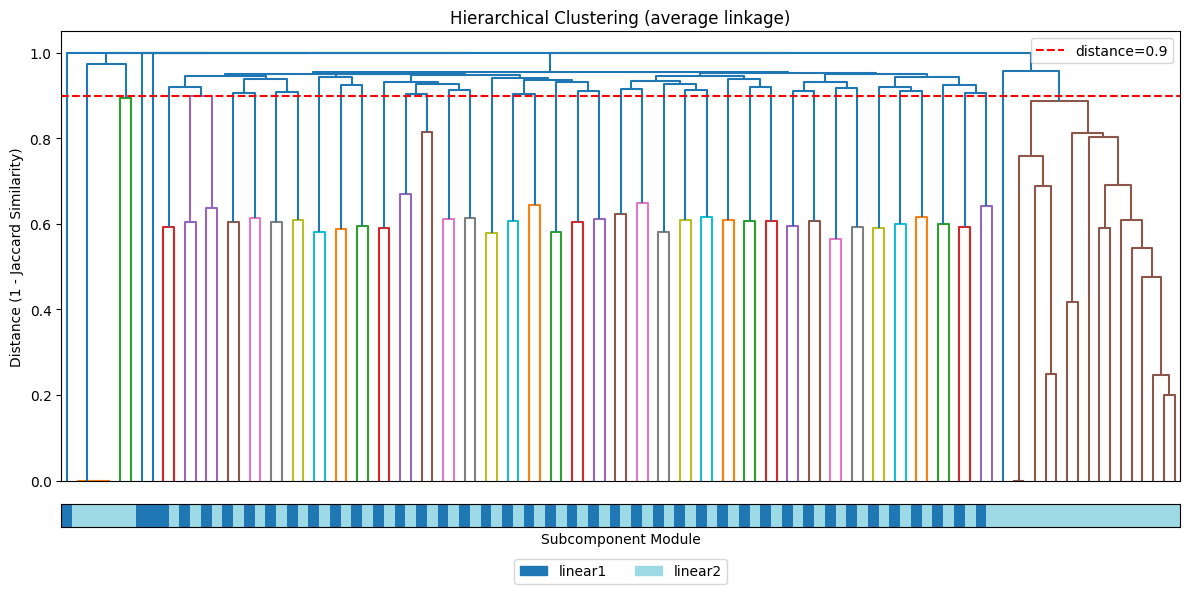

In [47]:
plot_clustering_from_results(
	results=coactivations_tms,
);

In [48]:

for group_key, group in coactivations_tms.items():
	print(f"{group_key = }:")
	for k, v in group.items():
		if isinstance(v, torch.Tensor):
			print(f"  {k}: {v.shape}")
		elif k == "labels":
			print(f"  labels: {set(v.tolist()) = }, {len(v) = }")
		else:
			print(f"  {k}: {v}")

group_key = 'group_0':
  co_occurrence_matrix: torch.Size([400, 400])
  marginal_counts: torch.Size([400])
  module_slices: {'linear1': slice(0, 200, None), 'linear2': slice(200, 400, None)}
  modules: ['linear1', 'linear2']
  labels: set(v.tolist()) = {'linear1', 'linear2'}, len(v) = 400
  total_samples: 500000
  activation_threshold: 0.1
  jaccard: torch.Size([400, 400])


In [49]:
tms_coc = coactivations_tms["group_0"]["co_occurrence_matrix"]

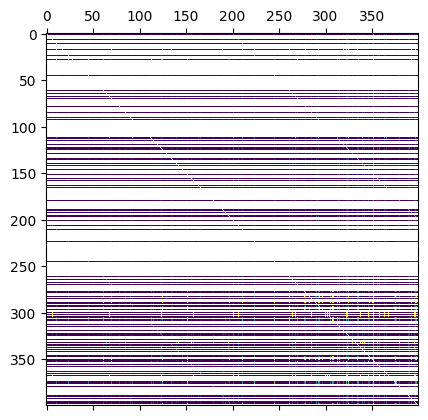

In [53]:
tms_coc_normalized = tms_coc / torch.diag(tms_coc).reshape(-1, 1)
plt.matshow(tms_coc_normalized.cpu().numpy(), cmap="viridis")

# 1 layer residual MLP

Number of alive elements: 150
Number of clusters: 101
Cluster sizes: [50  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1]


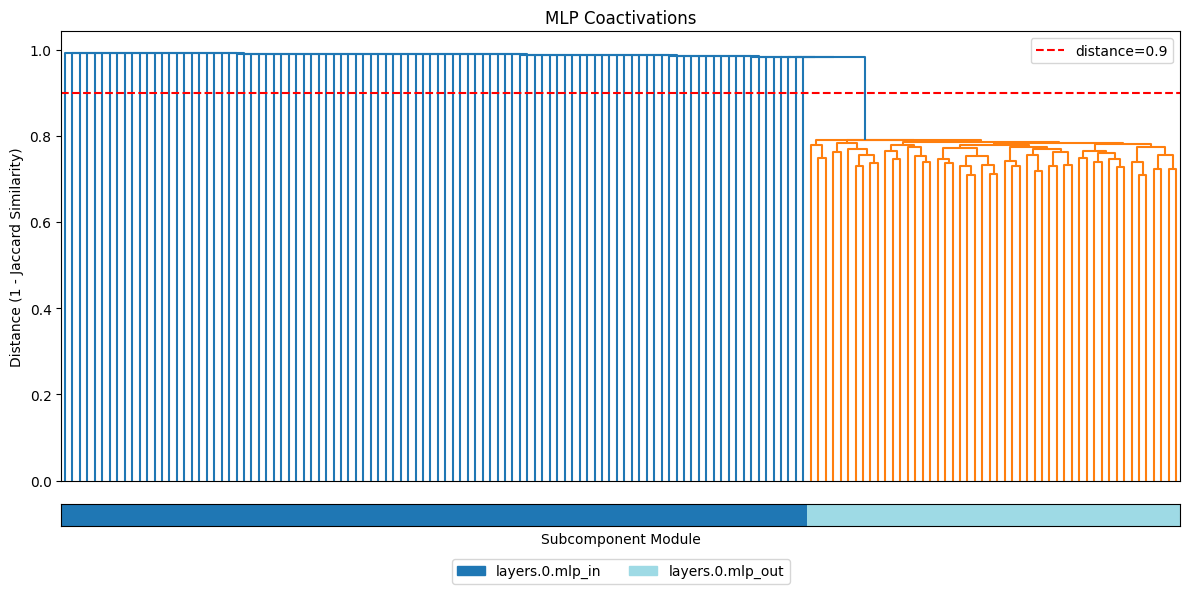

In [55]:
coactivations_mlp: CoactivationResults = get_coactivations(
    model_path=Path("data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    device=DEVICE,
)
plot_clustering_from_results(
    results=coactivations_mlp,
    title="MLP Coactivations",
);

# 3 layer residual MLP

In [57]:
coactivations_mlp3: CoactivationResults = get_coactivations(
    model_path=Path("data/mlp3-decomp/model_120000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None, 
    ),
    coactivations_kwargs=dict(
        module_groups=[[
            "layers.0.mlp_in",
            "layers.0.mlp_out",
            "layers.1.mlp_in",
            "layers.1.mlp_out",
            "layers.2.mlp_in",
            "layers.2.mlp_out",
        ]],
    ),
    device=DEVICE,
)

_, mlp3_clusters, _, mlp3_alive_mask = plot_clustering_from_results(
    coactivations_mlp3,
    group_key="group_0",
    linkage_method="average",
    threshold=0.8,
    # linkage_method="complete",
    # threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

ValidationError: 1 validation error for Config
gate_type
  Extra inputs are not permitted [type=extra_forbidden, input_value='scaled_sigmoid_gate_mlp', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/extra_forbidden

In [ ]:

submodules = coactivations_mlp3["group_0"]["labels"][mlp3_alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(mlp3_clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = mlp3_clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")